# Ejercicio 1
Implemente un perceptrón simple que aprenda la función lógica AND y la función
lógica OR, de 2 y de 4 entradas. Muestre la evolución del error durante el
entrenamiento. Para el caso de 2 dimensiones, grafique la recta discriminadora y todos
los vectores de entrada de la red.

In [28]:
import numpy as np
import matplotlib.pyplot as plt


class Perceptron:
    def __init__(self, input_size, learning_rate=0.01, epochs=100):
        self.weights = np.zeros(input_size + 1)  # +1 para el bias
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.errors = []

    def predict(self, X):
        h = np.dot(X, self.weights[1:]) + self.weights[0]  # w0 es el bias
        return np.where(h >= 0, 1, -1)

    def train(self, X, y):
        for _ in range(self.epochs):
            E = 0
            for xi, target in zip(X, y):
                y_pred = self.predict(xi)
                error = target - y_pred
                self.weights[1:] += self.learning_rate * error * xi
                self.weights[0] += self.learning_rate * error  # Ajuste del bias
                E += error**2
            self.errors.append(E)
            if E == 0:  # Si no hay errores, detener el entrenamiento
                break
           
    def plot_decision_boundary(self, X, y):
        # Definir los valores de x1
        x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        x1_vals = np.linspace(x1_min, x1_max, 100)

        # Ecuación de la recta: w0 + w1 * x1 + w2 * x2 = 0 => x2 = -(w0 + w1 * x1) / w2
        x2_vals = -(self.weights[0] + self.weights[1] * x1_vals) / self.weights[2]

        # Gráfico de los puntos y la recta
        plt.plot(x1_vals, x2_vals, 'b-', label='Recta discriminadora')
        plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='r', marker='o', label='Clase 1')
        plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='g', marker='x', label='Clase -1')

        plt.xlim([x1_min, x1_max])
        plt.ylim([x2_min, x2_max])
        plt.xlabel(r'$x_1$')
        plt.ylabel(r'$x_2$')
        plt.legend()
        plt.title('Recta discriminadora y puntos')
        plt.grid(True)
        plt.show()

    # Grafico la evolución del error
    def plot_error(self):
        plt.figure(figsize=(8,6))
        plt.plot(self.errors)
        plt.xlabel('Época')
        plt.ylabel('Error')
        plt.title('Evolución del Error durante el entrenamiento')
        plt.grid(True)
        plt.show()

### Caso compuerta AND

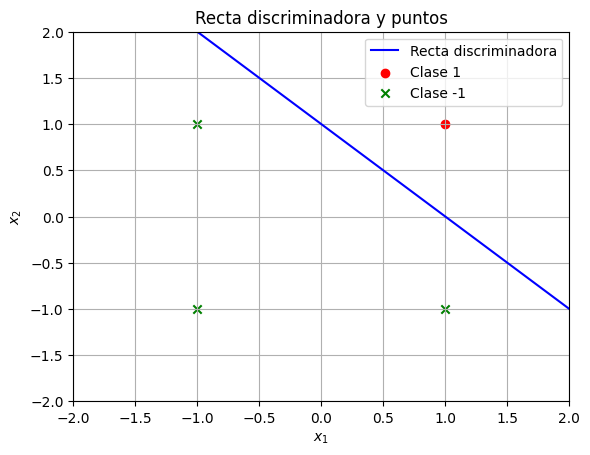

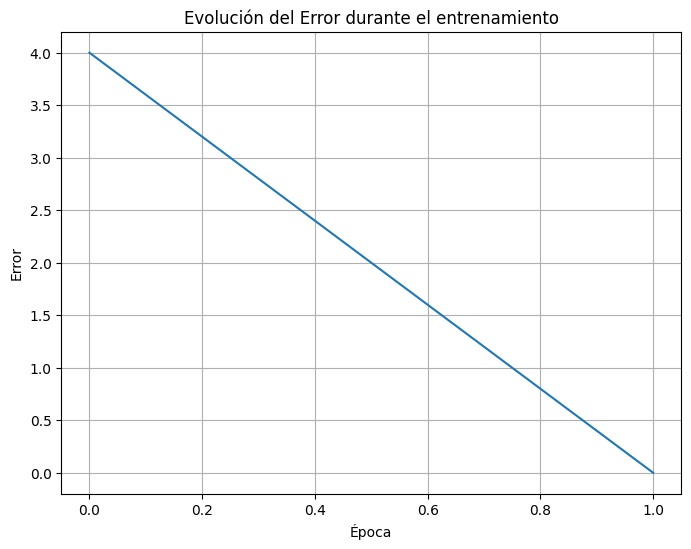

In [29]:
# Datos para la función AND
X_and = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
y_and = np.array([-1, -1, -1, 1])

# Entrenar para la función AND
perceptron_and = Perceptron(2,learning_rate=0.1, epochs=100)
perceptron_and.train(X_and, y_and)
perceptron_and.plot_decision_boundary(X_and, y_and)
perceptron_and.plot_error()

### Caso compuerta OR

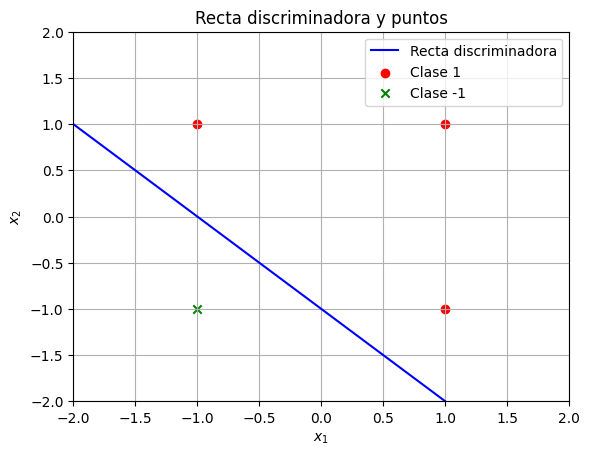

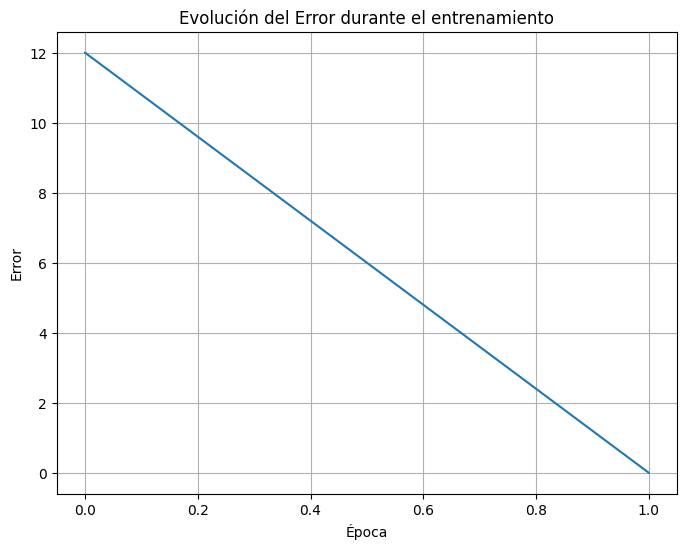

In [30]:
# Datos para la función OR
X_or = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
y_or = np.array([-1, 1, 1, 1])

# Entrenar para la función OR
perceptron_or = Perceptron(2,learning_rate=0.1, epochs=100)
perceptron_or.train(X_or, y_or)
perceptron_or.plot_decision_boundary(X_or, y_or)
perceptron_or.plot_error()

# Ejercicio 2

Determine numéricamente cómo varía la capacidad del perceptrón simple en función
del número de patrones enseñados.

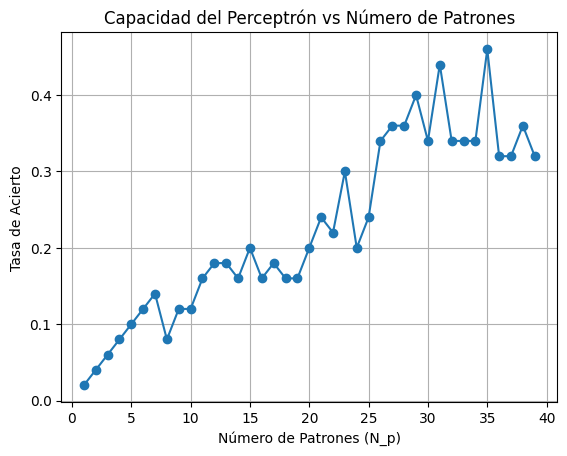

In [35]:
import numpy as np
import matplotlib.pyplot as plt


def generate_patterns(N, N_p):
    """
    Genera patrones de entrada aleatorios y etiquetas.
    N: Número de entradas (dimensiones).
    N_p: Número de patrones.
    """
    X = np.random.uniform(-1, 1, (N_p, N))
    y = np.random.choice([-1, 1], size=N_p)
    
    return X, y

def evaluate_perceptron(N, N_p_values, N_tot=100):
    """
    Evalúa el desempeño del perceptrón para distintos números de patrones N_p.
    N: Número de entradas.
    N_p_values: Lista con los diferentes números de patrones a probar.
    trials: Cantidad de veces que se repite el experimento para cada N_p.
    """
    success_rates = []

    for N_p in N_p_values:
        successes = 0
        for _ in range(N_tot):
            # Generar patrones aleatorios
            X, y = generate_patterns(N, N_p)
            # Crear y entrenar el perceptrón
            perceptron = Perceptron(input_size=N)
            perceptron.train(X, y)
            # Evaluar si clasifica correctamente
            y_pred = perceptron.predict(X)
            successes = np.sum((y-y_pred) == 0)  # Tasa de aciertos
        success_rate = successes / N_tot
        success_rates.append(success_rate)

    return success_rates

# Parámetros
N = 2  # Número de entradas
N_p_values = np.arange(1, 40)  # Número de patrones, de 1 a 40
trials = 50  # Número de pruebas para cada cantidad de patrones

# Evaluar
success_rates = evaluate_perceptron(N, N_p_values, trials)

# Graficar los resultados
plt.plot(N_p_values, success_rates, marker='o')
plt.xlabel('Número de Patrones (N_p)')
plt.ylabel('Tasa de Acierto')
plt.title('Capacidad del Perceptrón vs Número de Patrones')
plt.grid(True)
plt.show()
